In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [5]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

matplotlib: 3.9.2
scipy     : 1.13.1
seaborn   : 0.13.2
numpy     : 1.26.4
pandas    : 2.3.1



In [6]:
np.random.seed(42)

In [8]:
df = pd.read_csv('C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/Projetos de Machine Learning/dataset.csv')

In [9]:
df.head()

,usuario_id,grupo,latitude,longitude,conversao
0,1,A,35.669109,6.869443,1
1,2,B,6.497346,-7.494524,1
2,3,A,-34.285029,-170.768856,0
3,4,A,56.483104,-57.150782,1
4,5,A,33.251611,-43.129577,0


In [10]:
 taxa_conversao = df.groupby('grupo')['conversao'].mean()

In [11]:
print('Taxa de conversão por Grupo')
print(taxa_conversao)

Taxa de conversão por Grupo
grupo
A    0.300000
B    0.315686
Name: conversao, dtype: float64


In [12]:
grupo_A = df[df['grupo'] == 'A']
grupo_B = df[df['grupo'] == 'B']

In [13]:
taxa_conversao_A = grupo_A['conversao'].mean()
taxa_conversao_B = grupo_B['conversao'].mean()

In [14]:
taxa_conversao_A

0.3

In [15]:
taxa_conversao_B

0.3156862745098039

In [16]:
shapiro_A = stats.shapiro(grupo_A['conversao'])
shapiro_B = stats.shapiro(grupo_B['conversao'])
print(f'Teste de shapiro-Wilk para o Grupo-A: {shapiro_A}')
print(f'Teste de shapiro-Wilk para o Grupo-B: {shapiro_B}')

Teste de shapiro-Wilk para o Grupo-A: ShapiroResult(statistic=0.5755484295691086, pvalue=8.305357450336786e-33)
Teste de shapiro-Wilk para o Grupo-B: ShapiroResult(statistic=0.585129503103347, pvalue=4.3919138194577314e-33)


In [17]:
levene_test = stats.levene(grupo_A['conversao'], grupo_B['conversao'])
print(f'Teste de Levene para homogeneidade de variâncias: {levene_test}')

Teste de Levene para homogeneidade de variâncias: LeveneResult(statistic=0.2880082452976037, pvalue=0.5916193377766582)


In [19]:
t_stat, p_val = stats.ttest_ind(grupo_A['conversao'], grupo_B['conversao'])

In [20]:
print(f'Taxa de conversão do Grupo A: {grupo_A["conversao"].mean()}')
print(f'Taxa de conversão do Grupo B: {grupo_B["conversao"].mean()}')
print(f'Estatística t: {t_stat}')
print(f'Valor p: {p_val}')

Taxa de conversão do Grupo A: 0.3
Taxa de conversão do Grupo B: 0.3156862745098039
Estatística t: -0.5366639966474401
Valor p: 0.5916193377768858


In [ ]:
if p_val < 0.05:
    print("Rejeitamos a H0. Diferença estatisticamente significativa entre os grupos A e B")
else:
    print("Falhamos em rejeitar a H0. Não há diferença estatisticamente significativa entre os grupos A e B")

Falhamos em rejeitar a H0. Não há diferença estatisticamente significativa entre os grupos A e B


In [22]:
u_stat, p_val_mw = stats.mannwhitneyu(grupo_A['conversao'], grupo_B['conversao'])

In [23]:
print(f'Estatística U: {u_stat}')
print(f'Valor p do teste de Mann-Whitney: {p_val_mw}')

Estatística U: 122990.0
Valor p do teste de Mann-Whitney: 0.5914621529131736


In [26]:
alpha = 0.05
if p_val_mw < alpha:
    print("Rejeitamos a hipótose nula (H0). À Diferença estatisticamente significativa entre os grupos A e B")
else:
    print("Não rejeitamos a hipótese nula (H0). Não há diferença estatisticamente significativa entre os grupos A e B")

Não rejeitamos a hipótese nula (H0). Não há diferença estatisticamente significativa entre os grupos A e B


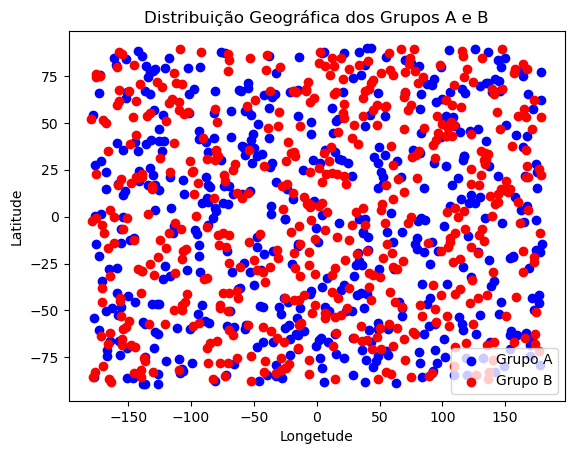

In [29]:
plt.scatter(grupo_A['longitude'], grupo_A['latitude'], c='blue', label='Grupo A')
plt.scatter(grupo_B['longitude'], grupo_B['latitude'], c='red', label='Grupo B')
plt.xlabel('Longetude')
plt.ylabel('Latitude')
plt.legend()
plt.title('Distribuição Geográfica dos Grupos A e B')
plt.show()

**Conclusão**

Com base na análise dos dados, não temos evidências estatísticas para afirmar que a campanha de Marketing apresenta diferença entre as regiões.

A região geográfica não tem influência na taxa média de conversão de compras.